# Chuẩn bị môi trường

In [8]:
import os
import csv
import cv2
import mediapipe as mp
from tqdm import tqdm
import matplotlib.pyplot as plt


# Tải dataset

In [9]:
# !kaggle datasets download -d furcifer/fane-facial-expressions-and-emotion-dataset -p ./Dts/ --unzip

In [10]:
DATASET_DIR = "../Dts/fane_data"          
OUTPUT_CSV = "../Output/face_landmarks.csv"
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

mp_face_mesh = mp.solutions.face_mesh

NUM_LANDMARKS = 478

# Đánh số 478 toạ độ

In [11]:
def danhsotoado():
    header = []
    for i in range(NUM_LANDMARKS):
        header += [f"x{i}", f"y{i}", f"z{i}"]
    header.append("label")
    return header

# Trích xuất 478 toạ độ từ ảnh

In [12]:
def trich_xuat_toa_do_tu_anh(face_mesh, image_path):
    """Trả về list 1434 giá trị (x,y,z * 478) hoặc None nếu không detect được mặt."""
    image = cv2.imread(image_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    # CV2 đọc ảnh theo Blue-Green-Red, nhưng mà Mediapipe đọc theo Red-Green-Blue dẫn đến quá trình trích xuất sai lệch.
    # Do vậy cần phải convert ảnh từ BGR sang RGB để trích xuất đúng.
    results = face_mesh.process(image_rgb)

    if not results.multi_face_landmarks: # Không tìm được mặt thì return None
        return None

    face_landmarks = results.multi_face_landmarks[0] # Nếu detect từ 2 mặt trở lên thì lấy cái mặt được detect đầu tiên để gắn toạ độ

    row = []
    for lm in face_landmarks.landmark:
        row.extend([lm.x, lm.y, lm.z]) # Lấy toạ độ (x,y,z) của 478 điểm

    return row

# Gắn nhãn cho mỗi ảnh

In [13]:
def load_label_id(class_id_path):
    """
    Đọc file Class_ID.txt dạng:
        0: angry
        1: disgust
        2: fear
        ...
    Trả về dict: {"angry": 0, "disgust": 1, "fear": 2, ...}
    """
    name_to_id = {}
    with open(class_id_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()          # bỏ khoảng trắng/xuống dòng thừa
            if not line:
                continue                 # bỏ qua dòng trống
            id_str, name = line.split(":", 1)   # tách theo dấu ":"
            class_id = int(id_str.strip())      # "0" → 0 (số nguyên)
            class_name = name.strip()           # " angry" → "angry"
            name_to_id[class_name] = class_id

    return name_to_id

In [15]:
header = danhsotoado()
class_mapping = load_label_id("Class_ID.txt")
rows_written = 0
rows_skipped = 0
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
with mp_face_mesh.FaceMesh(
    static_image_mode=True,      # bắt buộc True vì xử lý ảnh tĩnh, không phải xử lí theo thời gian thực
    max_num_faces=1,
    refine_landmarks=True,       # bật thêm landmark quanh mắt/môi cho chính xác hơn
    min_detection_confidence=0.5,
) as face_mesh, open(OUTPUT_CSV, "w", newline="") as f_out:

    writer = csv.writer(f_out)
    writer.writerow(header) # Tạo hàng tiêu đề cho file CSV

    labels = sorted(
        d for d in os.listdir(DATASET_DIR)
        if os.path.isdir(os.path.join(DATASET_DIR, d))
        if d.lower() != "confused"
    )
    print(f"Tìm thấy {len(labels)} nhãn: {labels}")
    count =0
    scan_fail =[0,0,0,0,0,0,0,0,0]
    scan_success =[0,0,0,0,0,0,0,0,0]
    for label in labels:
        label_dir = os.path.join(DATASET_DIR, label)
        image_files = [
            fn for fn in os.listdir(label_dir)
            if fn.lower().endswith(IMAGE_EXTENSIONS)
        ]
        for fn in tqdm(image_files, desc=f"Đang xử lý '{label}'"):
            image_path = os.path.join(label_dir, fn)
            landmarks = trich_xuat_toa_do_tu_anh(face_mesh, image_path)

            if landmarks is None:
                rows_skipped += 1
                scan_fail[count]+=1
                continue
            label_id = class_mapping.get(label, -1)  # mặc định -1 nếu không có trong mapping
            writer.writerow(landmarks + [label_id])
            rows_written += 1
            scan_success[count]+=1
        count +=1
print(f"\nXong! Ghi được {rows_written} dòng vào '{OUTPUT_CSV}'.")
print(f"Bỏ qua {rows_skipped} ảnh (không detect được mặt).")

Tìm thấy 8 nhãn: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'shy', 'surprise']


Đang xử lý 'angry':   0%|          | 0/1774 [00:00<?, ?it/s]

Đang xử lý 'surprise': 100%|██████████| 1854/1854 [00:12<00:00, 154.50it/s]


Xong! Ghi được 15061 dòng vào '../Output/face_landmarks.csv'.
Bỏ qua 567 ảnh (không detect được mặt).


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_CSV)

print(df.head(1).shape)
display(df.head())

(1, 1436)


,filepath,x0,y0,z0,x1,y1,z1,x2,y2,z2,...,x475,y475,z475,x476,y476,z476,x477,y477,z477,label
0,angry\PrivateTest_10131363.jpg,0.412960,0.720602,-0.026368,0.533168,0.692404,-0.138494,0.505769,0.699926,-0.052426,...,0.679694,0.440699,0.003713,0.651674,0.457678,0.003713,0.661904,0.488617,0.003713,0
1,angry\PrivateTest_10304478.jpg,0.765481,0.540116,-0.062077,0.842496,0.459341,-0.083692,0.784370,0.490414,-0.055224,...,0.839248,0.299028,0.145378,0.824727,0.311955,0.145378,0.827762,0.331678,0.145378,0
2,angry\PrivateTest_10590091.jpg,0.179508,0.814173,0.012174,0.165660,0.765717,-0.097918,0.192979,0.779454,-0.025342,...,0.433715,0.583686,-0.106283,0.386047,0.590987,-0.106283,0.406330,0.629385,-0.106283,0
3,angry\PrivateTest_12000629.jpg,0.666092,0.789253,-0.079635,0.721667,0.598571,-0.135272,0.670860,0.639177,-0.072666,...,0.704881,0.350680,0.141827,0.684324,0.380434,0.141827,0.708007,0.407944,0.141827,0
4,angry\PrivateTest_12008383.jpg,0.389756,0.515957,-0.075051,0.353237,0.418384,-0.111087,0.378334,0.449378,-0.069198,...,0.529456,0.227885,-0.009179,0.506352,0.248409,-0.009179,0.529612,0.267961,-0.009179,0


# Xuất báo cáo thống kê, biểu đồ phân bố nhãn

In [ ]:
for idx, label in enumerate(labels):
    print(f"Số lượng bỏ qua của {label} là {scan_fail[idx]}")
for idx, label in enumerate(labels):
    print(f"Số lượng quét được của {label} là {scan_success[idx]}")


Số lượng bỏ qua của angry là 105
Số lượng bỏ qua của disgust là 14
Số lượng bỏ qua của fear là 83
Số lượng bỏ qua của happy là 60
Số lượng bỏ qua của neutral là 48
Số lượng bỏ qua của sad là 140
Số lượng bỏ qua của surprise là 50
Số lượng quét được của angry là 853
Số lượng quét được của disgust là 97
Số lượng quét được của fear là 941
Số lượng quét được của happy là 1714
Số lượng quét được của neutral là 1185
Số lượng quét được của sad là 1107
Số lượng quét được của surprise là 781


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (7,) and arg 1 with shape (9,).

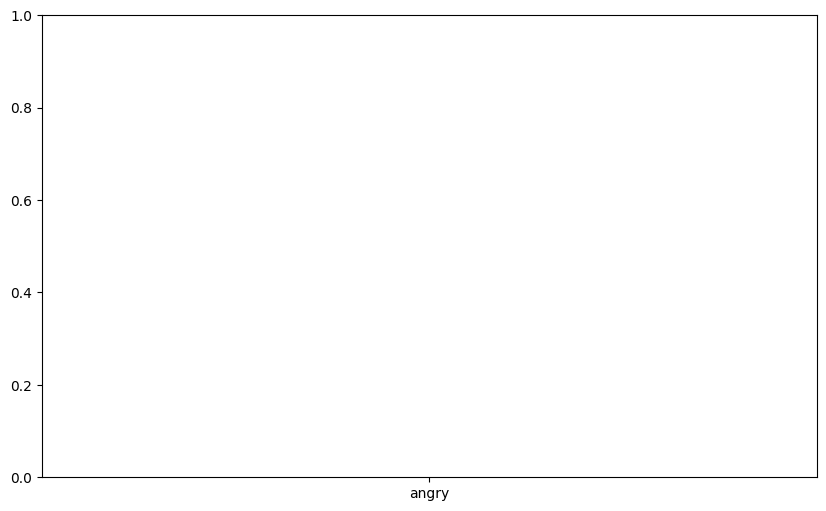

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, scan_fail, label='Fail',color="navy", alpha=1)
plt.bar(labels, scan_success, label='Success',color="blue", alpha=0.2)

plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Bar Chart')
plt.legend()
bar1 = plt.bar(labels, scan_fail, alpha=0)
bar2 = plt.bar(labels, scan_success, alpha=0)
plt.tight_layout()
plt.bar_label(bar1, padding=3)
plt.bar_label(bar2, padding=3)
plt.savefig('bar_chart.png', dpi=300)
plt.close()